# **Machine Learning Analysis (H1 + H2)**

In this section, rainfall and time of day variables are combined to build a predictive model for fatality rates.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
rain_df = pd.read_csv("RainfallxFatalityRateTable.csv")
daynight_df = pd.read_csv("DayxNightFatality.csv", sep=";", skiprows=3)

daynight_df.columns = [
    "IGNORE1",
    "YEAR",
    "DAYLIGHT",
    "ACCIDENTS",
    "FATALITIES",
    "RATE",
    "IGNORE2"
]




In [ ]:
daynight_df = daynight_df[[
    "YEAR",
    "DAYLIGHT",
    "ACCIDENTS",
    "FATALITIES",
    "RATE"
]]

In [ ]:
daynight_df["ACCIDENTS"] = daynight_df["ACCIDENTS"].astype(str).str.replace(",", "").astype(float)
daynight_df["FATALITIES"] = daynight_df["FATALITIES"].astype(str).str.replace(",", "").astype(float)
daynight_df["RATE"] = daynight_df["RATE"].astype(float)

In [ ]:
daynight_df.head()

,YEAR,DAYLIGHT,ACCIDENTS,FATALITIES,RATE
0,2021,Day,129444.0,3193.0,0.024667
1,2021,Night,53403.0,1963.0,0.036758
2,2022,Day,132009.0,3054.0,0.023135
3,2022,Night,60415.0,1992.0,0.032972
4,2023,Day,154878.0,3781.0,0.024413


In [ ]:
rain_df.head()

,YEAR,MONTH,ACCIDENTS,FATALITIES,RAINFALL,FATALITY RATE (FATALITIES/ACCIDENTS)
0,2020,1,"11,880",306,44.8,0.025758
1,2020,2,"10,925",292,71.6,0.026728
2,2020,3,"10,705",306,50.2,0.028585
3,2020,4,"5,776",244,38.6,0.042244
4,2020,5,"8,133",286,50.6,0.035165


In [ ]:
yearly_rainfall = rain_df.groupby("YEAR")["RAINFALL"].mean().reset_index()

yearly_rainfall.columns = ["YEAR", "AVG_RAINFALL"]

yearly_rainfall

,YEAR,AVG_RAINFALL
0,2020,29.725000
1,2021,32.883333
2,2022,32.950000
3,2023,42.525000
4,2024,33.508333


In [ ]:
df_ml = pd.merge(daynight_df, yearly_rainfall, on="YEAR", how="inner")

df_ml

,YEAR,DAYLIGHT,ACCIDENTS,FATALITIES,RATE,AVG_RAINFALL
0,2021,Day,129444.0,3193.0,0.024667,32.883333
1,2021,Night,53403.0,1963.0,0.036758,32.883333
2,2022,Day,132009.0,3054.0,0.023135,32.950000
3,2022,Night,60415.0,1992.0,0.032972,32.950000
4,2023,Day,154878.0,3781.0,0.024413,42.525000
5,2023,Night,74844.0,2540.0,0.033937,42.525000
6,2024,Day,174332.0,3672.0,0.021063,33.508333
7,2024,Night,86916.0,2476.0,0.028487,33.508333


In [ ]:
df_ml["DAYLIGHT_ENC"] = df_ml["DAYLIGHT"].map({
    "Day": 0,
    "Night": 1
})

df_ml

,YEAR,DAYLIGHT,ACCIDENTS,FATALITIES,RATE,AVG_RAINFALL,DAYLIGHT_ENC
0,2021,Day,129444.0,3193.0,0.024667,32.883333,0
1,2021,Night,53403.0,1963.0,0.036758,32.883333,1
2,2022,Day,132009.0,3054.0,0.023135,32.950000,0
3,2022,Night,60415.0,1992.0,0.032972,32.950000,1
4,2023,Day,154878.0,3781.0,0.024413,42.525000,0
5,2023,Night,74844.0,2540.0,0.033937,42.525000,1
6,2024,Day,174332.0,3672.0,0.021063,33.508333,0
7,2024,Night,86916.0,2476.0,0.028487,33.508333,1


In [ ]:
X = df_ml[["YEAR", "AVG_RAINFALL", "DAYLIGHT_ENC"]]
y = df_ml["RATE"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)

In [ ]:
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Linear R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Linear R2: -1.4068769507961214
Random Forest R2: -11.080685968552
Linear RMSE: 0.002188249316568903
Random Forest RMSE: 0.00490247801900616


In [35]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, dt_pred))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))

Decision Tree R2: -2.8371388408581804
Decision Tree RMSE: 0.0027629537450005355


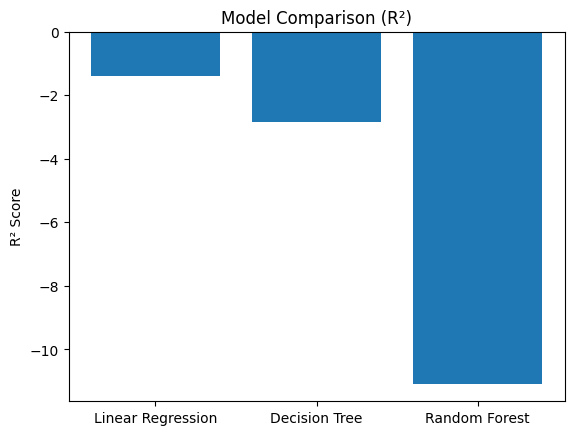

In [36]:
models = ["Linear Regression", "Decision Tree", "Random Forest"]
r2_scores = [-1.40, r2_score(y_test, dt_pred), -11.08]

plt.bar(models, r2_scores)
plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")
plt.show()

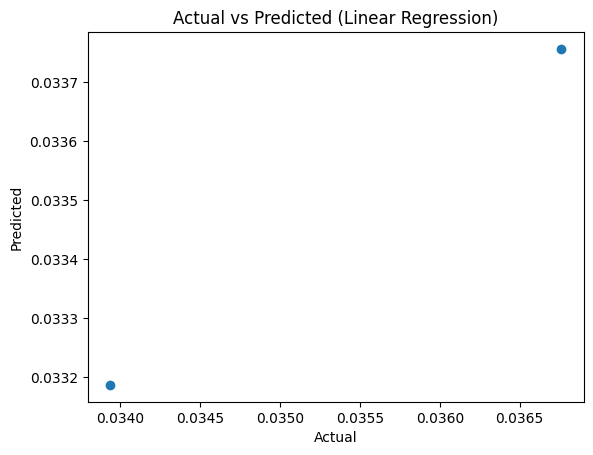

In [37]:
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

# **Machine Learning analysis**

Machine Learning Analysis

In this part, rainfall and time of day were used together as input features to predict fatality rates. The dataset was split into training and testing sets. Three supervised learning models were applied: Linear Regression, Decision Tree, and Random Forest.

The results showed that all models performed poorly, with negative R² scores. This indicates that the selected features are not sufficient to accurately predict fatality rates.